In [1]:
import ptatoolbox as ptb
import pta_catalog as pc
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import libstempo as T
import corner
import typer
import s2fft
import os, glob

import enterprise.signals.parameter as parameter
from enterprise.pulsar import Pulsar, Tempo2Pulsar
from enterprise.signals import white_signals
from enterprise.signals import utils
from enterprise.signals import gp_signals
from enterprise.signals import signal_base
from enterprise_extensions import model_utils
from PTMCMCSampler.PTMCMCSampler import PTSampler

from scipy.special import sph_harm_y as sph_harm

PINT not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


In [2]:
SPHERE = {
    'coords': 'sphere',
    'params': {
        'seed_coord': 42,
        'radius': 1.0,
    }
}

CAP = {
    'coords': 'cap',
    'params': {
        'seed_coord': 42,
        'radius': 1.0,
        'ra_0': 0.0, 
        'dec_0': 0.0, 
        'alpha': 30.0,
    }
}

nside: int = 100
sample = "psr_test_1"
lmax = 2 * nside

In [3]:
dm = ptb.utils.DataManager("../data")
path = dm.create_experiment("observations")
datapath = dm.raw / sample
parpath = datapath / "par" / "*.par"
timpath = datapath / "tim" / "*.tim"

parfiles = sorted(glob.glob(str(parpath)))
timfiles = sorted(glob.glob(str(timpath)))

In [4]:
psrs = []
for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t, timing_package='tempo2')
    psrs.append(psr)

In [5]:
psrcat = pc.load_catalog(datapath, name=sample)
print(psrcat)

psr_test_1 catalog
    TYPE  PSRJ        RAJD      DECJD          F0            F1       PMRA  \
0    SIM    J0  212.658058 -41.074030    0.895978 -1.288000e-15  93.001084   
1    SIM    J1  245.191828  25.407419    1.792264 -4.757000e-16  -2.599978   
2    SIM   J10  305.488470  71.216178   30.471214 -5.387000e-17  44.730001   
3    SIM  J100  243.295791 -17.815378    1.721552 -1.364000e-16  -6.190320   
4    SIM  J101   17.574895  -6.357964  348.188640 -5.633000e-15 -12.000002   
..   ...   ...         ...        ...         ...           ...        ...   
145  SIM   J95   17.731657  15.786909  301.376193 -9.782000e-16   2.399987   
146  SIM   J96  276.808132  24.982041    2.095412 -2.895000e-15 -10.500917   
147  SIM   J97  178.388981  -7.039900    0.329807 -6.914000e-17  26.499382   
148  SIM   J98  250.367088   8.761913   30.467142 -1.368000e-16   0.000004   
149  SIM   J99  312.222774 -79.969881   67.376581 -7.096000e-17  -2.459998   

         PMDEC        PX      DM  
0   -14.9

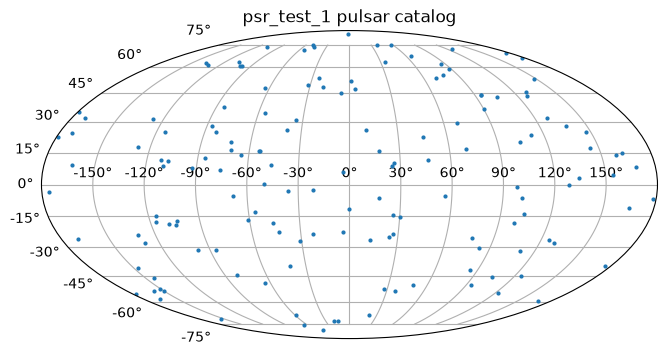

In [6]:
pc.plot_catalog(psrcat, datapath, show=True)

J100
243.2957912004167
-17.81537777777778


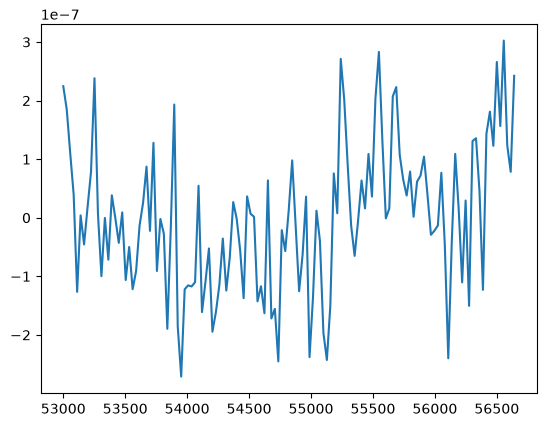

In [7]:
psr = psrs[3]
print(psr.name)
print(psr.phi * 180/np.pi)
print((np.pi/2 - psr.theta) * 180/np.pi)
plt.plot(psr.toas/(24*3600), psr.residuals)
plt.show()


In [8]:
# find the maximum time span to set GW frequency sampling
tmin = [p.toas.min() for p in psrs]
tmax = [p.toas.max() for p in psrs]
Tspan = np.max(tmax) - np.min(tmin)

##### parameters and priors #####

# white noise parameters
# EFAC: обычно варьируется в пределах от 0.1 до 5.0
efac = parameter.Uniform(0.1, 5.0)

##### Set up signals #####

# white noise
ef = white_signals.MeasurementNoise(efac=efac)

# timing model
tm = gp_signals.TimingModel()

# full model is sum of components
model = ef + tm

# initialize PTA
pta = signal_base.PTA([model(psr) for psr in psrs])

In [9]:
xs = {par.name: par.sample() for par in pta.params}
print(xs)

{'J0_efac': 4.978509653014583, 'J100_efac': 1.0981968210850794, 'J101_efac': 1.6018311153024456, 'J102_efac': 3.678433066981198, 'J103_efac': 3.8336963588227526, 'J104_efac': 0.4881173250468982, 'J105_efac': 4.5870925461515855, 'J106_efac': 4.905226828462752, 'J107_efac': 4.89309060256241, 'J108_efac': 3.4081424002777227, 'J109_efac': 0.5509541695435951, 'J10_efac': 0.9788540101737832, 'J110_efac': 0.9840113237636048, 'J111_efac': 4.892803238098269, 'J112_efac': 4.019379993111379, 'J113_efac': 4.560235935429408, 'J114_efac': 0.19021340066191209, 'J115_efac': 1.9012968688621013, 'J116_efac': 4.058349230096529, 'J117_efac': 3.8127416421351037, 'J118_efac': 1.1930799767643159, 'J119_efac': 1.7938669581015723, 'J11_efac': 0.41576869236687763, 'J120_efac': 1.715275847976121, 'J121_efac': 4.04043660837502, 'J122_efac': 0.8020012900971271, 'J123_efac': 0.8971548456161319, 'J124_efac': 0.8712158338754545, 'J125_efac': 1.367826970733451, 'J126_efac': 2.584714180727052, 'J127_efac': 2.5669035835

In [ ]:
# Получаем начальную точку для сэмплера
xs = {par.name: par.sample() for par in pta.params}

# Настраиваем сэмплер
sampler = PTSampler(
    ndim=len(pta.params),
    logl=pta.get_lnlikelihood,
    logp=pta.get_lnprior,
    cov=np.diag(np.ones(len(pta.params))) * 0.01,
    outDir= str(datapath / 'chains/white_noise_only')
)

N = 100000
x0 = np.hstack([p.sample() for p in pta.params])
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

In [10]:
chain = np.loadtxt(str(datapath/'chains/white_noise_only/chain_1.txt'))
pars = sorted(xs.keys())
burn = int(0.25 * chain.shape[0])

In [ ]:

truths = [1.0, 4.33, np.log10(5e-14)]
corner.corner(chain[burn:,:-4], 30, truths=truths, labels=pars)

In [13]:
efac_val = np.median(chain)
sigma = np.sqrt((efac_val * psr.toaerrs)**2)
C_time = np.diag(sigma**2)

array([[1.33458499e-13, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.33458499e-13, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.33458499e-13, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.33458499e-13, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.33458499e-13, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.33458499e-13]], shape=(131, 131))